In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve

shots = pd.read_parquet("data/shots_features.parquet")

FEATURES = ["distance", "angle", "is_header", "is_open_play"]
TARGET = "is_goal"

print(shots[FEATURES + [TARGET]].describe())
print(f"\nShape: {shots.shape}")
print(f"\nNull counts:\n{shots[FEATURES + [TARGET]].isnull().sum()}")

          distance        angle    is_header  is_open_play      is_goal
count  9168.000000  9168.000000  9168.000000   9168.000000  9168.000000
mean     19.046284    25.386265     0.163067      0.944699     0.110602
std       8.685988    15.697708     0.369447      0.228579     0.313656
min       0.632456     0.299683     0.000000      0.000000     0.000000
25%      12.000417    15.114400     0.000000      1.000000     0.000000
50%      18.261709    19.682607     0.000000      1.000000     0.000000
75%      25.269300    31.536490     0.000000      1.000000     0.000000
max      74.867416   179.999260     1.000000      1.000000     1.000000

Shape: (9168, 12)

Null counts:
distance        0
angle           0
is_header       0
is_open_play    0
is_goal         0
dtype: int64


In [3]:
X = shots[FEATURES]
Y = shots[TARGET]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"Train: {X_train.shape[0]} shots, {Y_train.sum()} goals ({Y_train.mean():.3f})")
print(f"Test:  {X_test.shape[0]} shots, {Y_test.sum()} goals ({Y_test.mean():.3f})")

Train: 7334 shots, 811 goals (0.111)
Test:  1834 shots, 203 goals (0.111)


In [4]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, Y_train)

Y_prob = model.predict_proba(X_test)[:, 1]

brier = brier_score_loss(Y_test, Y_prob)
auc = roc_auc_score(Y_test, Y_prob)

print(f"Brier score: {brier:.4f}  (naive baseline: 0.0987)")
print(f"AUC:         {auc:.4f}")
print(f"\nCoefficients:")
for feat, coef in zip(FEATURES, model.coef_[0]):
    print(f"  {feat:<15} {coef:.4f}")
print(f"  {'intercept':<15} {model.intercept_[0]:.4f}")

Brier score: 0.0822  (naive baseline: 0.0987)
AUC:         0.8042

Coefficients:
  distance        -0.1320
  angle           0.0233
  is_header       -1.3465
  is_open_play    -1.7303
  intercept       1.1521


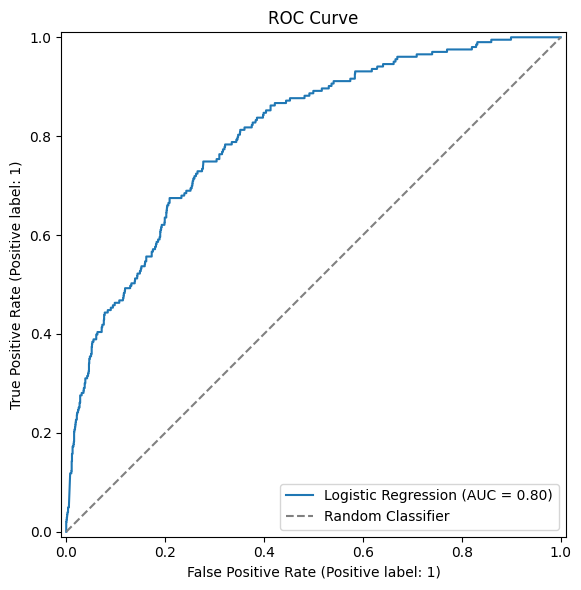

In [8]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(Y_test, Y_prob, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve_model_v1.png", dpi=150)
plt.show()

Correlation with StatsBomb xG: 0.8228


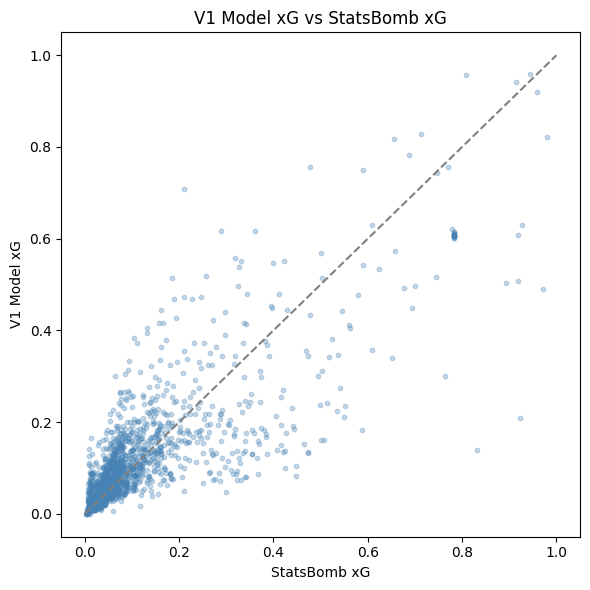

In [9]:
sb_xg = shots.loc[X_test.index, "shot_statsbomb_xg"]

correlation = np.corrcoef(sb_xg, Y_prob)[0, 1]
print(f"Correlation with StatsBomb xG: {correlation:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sb_xg, Y_prob, alpha=0.3, s=10, color="steelblue")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("StatsBomb xG")
ax.set_ylabel("V1 Model xG")
ax.set_title("V1 Model xG vs StatsBomb xG")
plt.tight_layout()
plt.savefig("outputs/xg_comparison_scatter_v1.png", dpi=150)
plt.show()

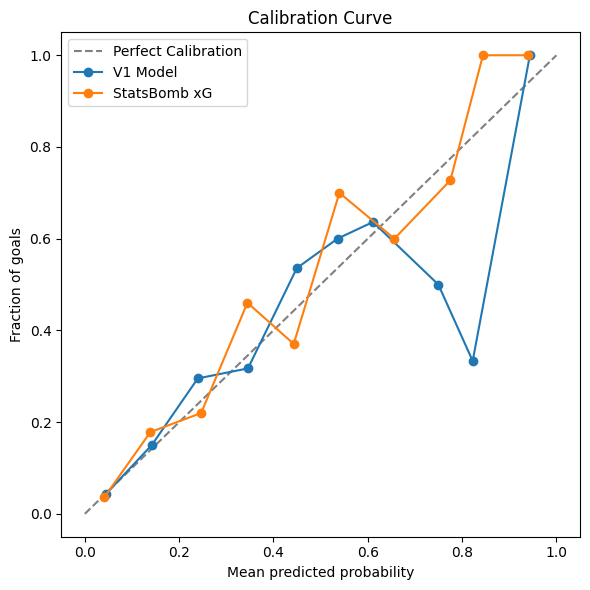

In [10]:
from sklearn.calibration import calibration_curve

prob_true_model, prob_pred_model = calibration_curve(Y_test, Y_prob, n_bins=10)
prob_true_sb, prob_pred_sb = calibration_curve(
    Y_test,
    shots.loc[X_test.index, "shot_statsbomb_xg"],
    n_bins=10
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
ax.plot(prob_pred_model, prob_true_model, marker="o", label="V1 Model")
ax.plot(prob_pred_sb, prob_true_sb, marker="o", label="StatsBomb xG")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of goals")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/calibration_curve_v1.png", dpi=150)
plt.show()

## Model Interpretation

_You can find the graphs for each model under the outputs directory. Each model has a ROC curve, a comparison scatter plot, and a calibration curve_

### V1 Model
The V1 logistic regression model uses features such as distance, angle, is_header, is_open_play. It underestimates probability on high-quality chances (predicted >0.6), and is overconfident on shots the model assigns 0.8 xG convert at approximately 30% in reality. The StatsBomb's model
uses features unavailable in this first version of my model, and those missing features drive the difference on genuine big chances.

The negative coefficient (-1.73) for is_open_play is counterintuitive but correct,since the feature groups penalties with corners and free kicks under is_open_play = 0. Penalties convert at ~75–80% from a fixed central position; controlling for distance
and angle, the model correctly learns that non-open-play shots outperform their spatial position. A cleaner implementation would separate is_penalty as a distinct feature — this is the primary candidate for V2.